In [2]:
import pandas as pd

df = pd.read_csv('/home/sga/Code/FAIRFluids/fairfluids/data/csvs/exp_ChCl_glycerol_withpredjournalpaper.csv')
df

,Error(cP),Viscosity(cP),molar ratio of DES (mol/mol),mole fraction of water (mol/mol),temperature (K),DOI
0,NG,60.2000,0.5,0.249766,313.150,10.1016/j.aca.2012.12.019
1,0.0063695,1.2739,0.5,1.000000,283.150,10.1016/j.fluid.2014.01.028
2,0.004918,0.9836,0.5,1.000000,293.150,10.1016/j.fluid.2014.01.028
3,0.003957,0.7914,0.5,1.000000,303.150,10.1016/j.fluid.2014.01.028
4,0.003246,0.6492,0.5,1.000000,313.150,10.1016/j.fluid.2014.01.028
...,...,...,...,...,...,...
312,NG,109.6180,0.5,0.000000,313.044,Abdullah and Kadhom (IJERD)
313,NG,66.2550,0.5,0.000000,323.065,Abdullah and Kadhom (IJERD)
314,NG,43.7360,0.5,0.000000,333.087,Abdullah and Kadhom (IJERD)
315,NG,28.6610,0.5,0.000000,343.111,Abdullah and Kadhom (IJERD)


In [24]:
df['Viscosity(cP)'] = df['Viscosity(cP)'] / 10
df = df[df['molar ratio of DES (mol/mol)'] == 0.5]

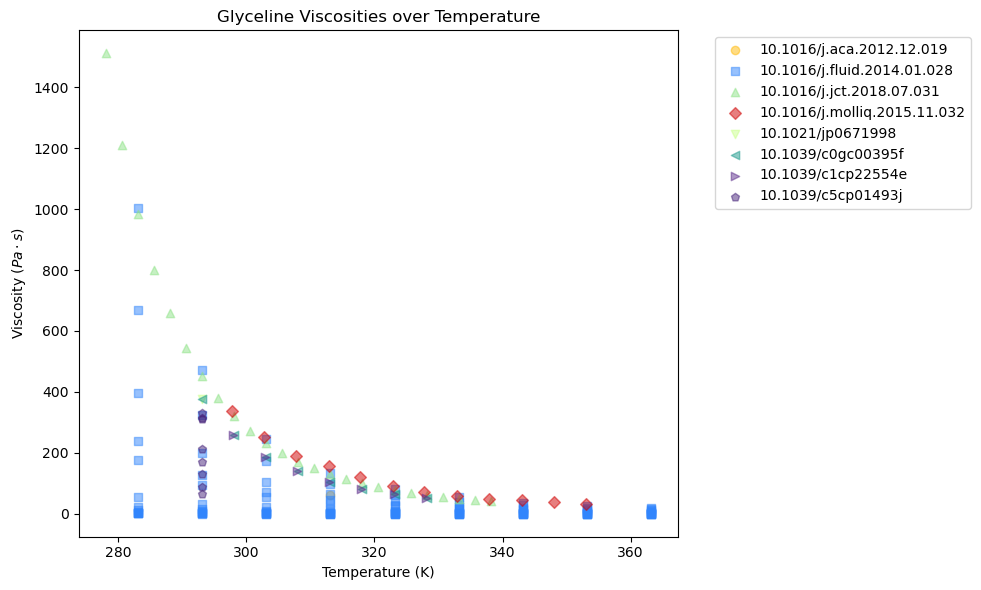

In [29]:
import matplotlib.pyplot as plt

# Define colors and markers
beautiful_colors = [
    '#ffba08',  # Amber Flame
    '#3185fc',  # Azure Blue
    '#8fe388',  # Light Green
    '#d00000',  # Brick Ember
    '#cbff8c',  # Lime Cream
    '#1b998b',  # Verdigris
    '#5d2e8c',  # Rebecca Purple
    '#46237a',  # Indigo Velvet
    '#ff7b9c',  # Petal Rouge
    '#ff9b85',  # Salmon
]

# Define marker symbols for each DOI
marker_symbols = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

plt.figure(figsize=(10, 6))
for idx, doi in enumerate(df['DOI'].unique()):
    if doi == 'Abdullah and Kadhom (IJERD)':
        continue
    mask = df['DOI'] == doi
    color = beautiful_colors[idx % len(beautiful_colors)]
    marker = marker_symbols[idx % len(marker_symbols)]
    plt.scatter(df[mask]['temperature (K)'], df[mask]['Viscosity(cP)'], alpha=0.5, label=doi, color=color, marker=marker)
plt.xlabel('Temperature (K)')
plt.ylabel('Viscosity ($Pa \\cdot s$)')
plt.title('Glyceline Viscosities over Temperature')
plt.grid(False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
import numpy as np

# Arrhenius plot: ln(viscosity) vs 1/(RT)

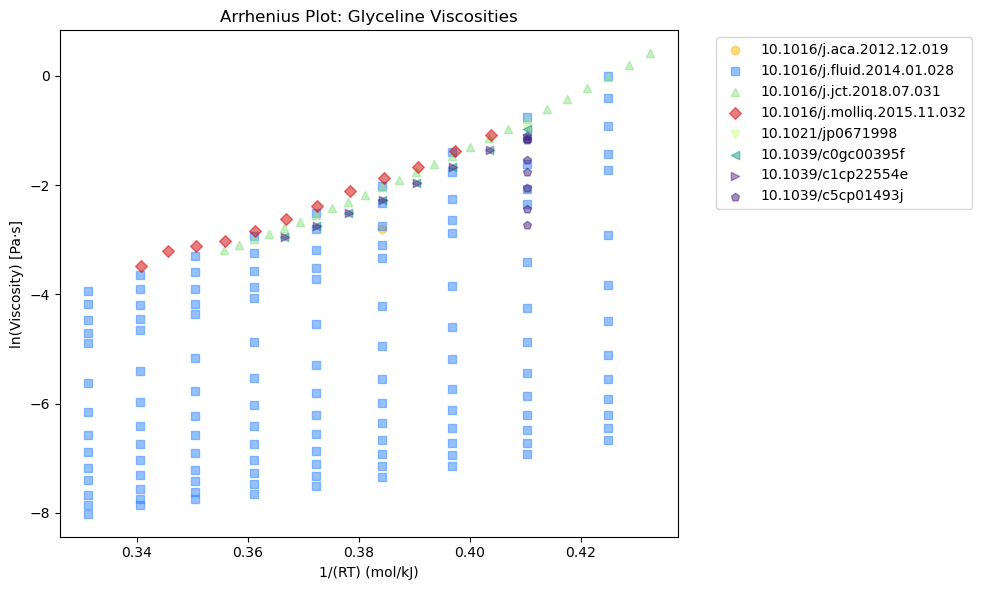

In [28]:
R = 8.314  # J/(mol·K)

# Define colors and markers
beautiful_colors = [
    '#ffba08',  # Amber Flame
    '#3185fc',  # Azure Blue
    '#8fe388',  # Light Green
    '#d00000',  # Brick Ember
    '#cbff8c',  # Lime Cream
    '#1b998b',  # Verdigris
    '#5d2e8c',  # Rebecca Purple
    '#46237a',  # Indigo Velvet
    '#ff7b9c',  # Petal Rouge
    '#ff9b85',  # Salmon
]

# Define marker symbols for each DOI
marker_symbols = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

plt.figure(figsize=(10, 6))
for idx, doi in enumerate(df['DOI'].unique()):
    if doi == 'Abdullah and Kadhom (IJERD)':
        continue
    mask = df['DOI'] == doi
    # Convert viscosity from cP to Pa·s (divide by 1000)
    viscosity_pas = df[mask]['Viscosity(cP)'] / 1000
    temperature = df[mask]['temperature (K)']
    
    # Calculate 1/(RT) in units of 1/(kJ/mol)
    x = 1000 / (R * temperature)  # multiply by 1000 to get kJ instead of J
    y = np.log(viscosity_pas)
    
    color = beautiful_colors[idx % len(beautiful_colors)]
    marker = marker_symbols[idx % len(marker_symbols)]
    
    plt.scatter(x, y, alpha=0.5, label=doi, color=color, marker=marker)

plt.xlabel('1/(RT) (mol/kJ)')
plt.ylabel('ln(Viscosity) [Pa·s]')
plt.title('Arrhenius Plot: Glyceline Viscosities')
plt.grid(False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()